In [145]:
import matplotlib.pyplot as plt
import numpy as np
import pdbtools
import potential
import torch
import torch.nn as nn
from icemaker import Icemaker, radial_profile_3d
from scipy.interpolate import CubicSpline
from skimage.feature import peak_local_max
from tqdm import tqdm

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def plot3d(vol):
    fig, axes = plt.subplots(1, 3, dpi=200, constrained_layout=True)
    for i, ax in enumerate(axes.ravel()):
        im = ax.imshow(vol.sum(i))
        ax.set(xticks=[], yticks=[], title=f"projection along axis {i}")
        fig.colorbar(im, ax=ax, location="bottom")
    plt.show()


def plot_slices(
    vol, start_idx=0, end_idx=None, axis=0, ylabel=None, vmin=None, vmax=None
):
    nslices = 5
    sh = vol.shape
    if end_idx is None:
        idx_length = sh[axis] - start_idx - 1
        end_idx = start_idx + idx_length
    else:
        idx_length = end_idx - start_idx
    idx_interval = idx_length // nslices
    indices = torch.linspace(start_idx, end_idx, nslices).type(torch.int)

    fig, axes = plt.subplots(1, 5, dpi=200, figsize=(8, 2.8), constrained_layout=True)
    for ax, i in zip(axes.ravel(), indices):
        ax.set(xticks=[], yticks=[])
        if axis == 0:
            im = ax.imshow(vol[i, :, :], vmin=vmin, vmax=vmax)
        elif axis == 1:
            im = ax.imshow(vol[:, i, :], vmin=vmin, vmax=vmax)
        elif axis == 2:
            im = ax.imshow(vol[:, :, i], vmin=vmin, vmax=vmax)
        ax.set_title(f"Slice {i}")
        fig.colorbar(im, ax=ax, location="bottom")

    if ylabel is not None:
        axes[0].set_ylabel(ylabel)
    # plt.suptitle(f"Slices along axis {axis}")
    plt.show()

In [3]:
fftn = lambda array: torch.fft.fftshift(torch.fft.fftn(torch.fft.ifftshift(array)))
ifftn = lambda array: torch.fft.fftshift(torch.fft.ifftn(torch.fft.ifftshift(array)))

## Try class

In [51]:
n = 200
dx = 0.5
super_sampling_factor = 4
icemake = Icemaker(n=n, dx=dx)

In [52]:
icemake.get_mdsim(trim_size=100)

12928909it [00:01, 8852339.23it/s]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 91/91 [07:21<00:00,  4.85s/it]


In [166]:
icemake.mdsim_ice_deltas.element_size()

4

In [167]:
icemake.mdsim_ice_deltas.nelement()

728000000

In [170]:
728000000 * 4 / 1000000/91

32.0

In [53]:
icemake.get_mdsim_averaged_f_kernel()

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 91/91 [00:02<00:00, 42.99it/s]


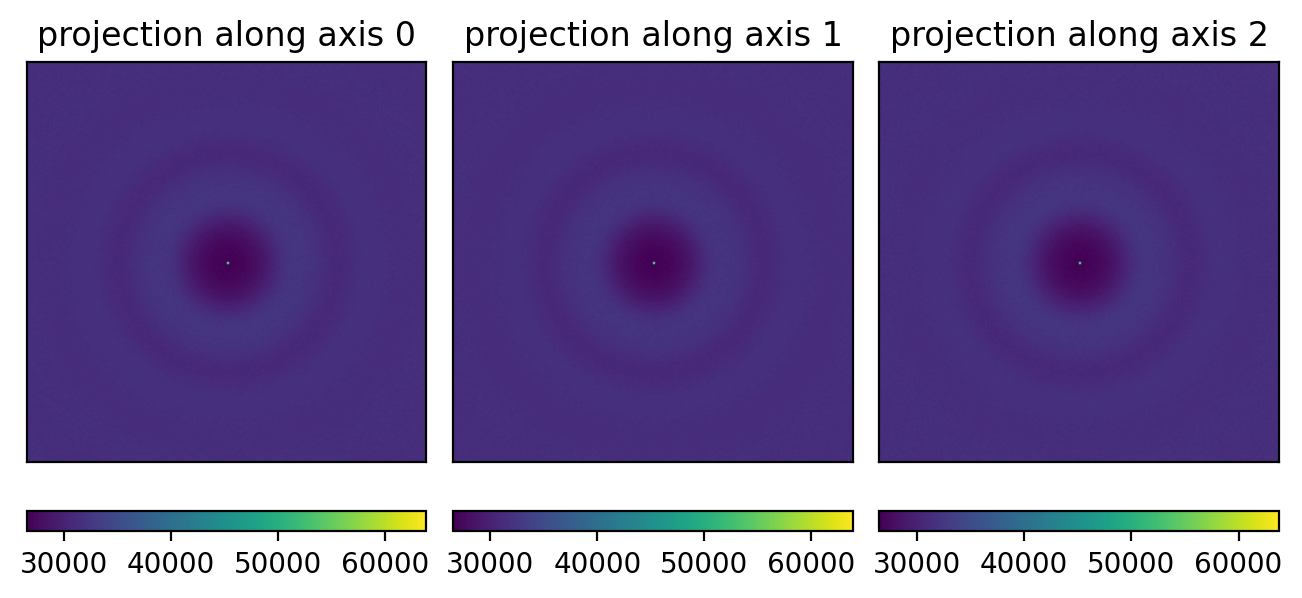

In [54]:
plot3d(icemake.mdsim_ice_deltas_f)

In [172]:
torch.save(icemake.mdsim_ice_deltas_f, 'mdsim_f_kernel_averaged_200x200x200_0.5A.pt')

In [56]:
mdsim_ice_deltas_f_abs_avg_radial = radial_profile_3d(icemake.mdsim_ice_deltas_f)

In [57]:
k = torch.arange(len(mdsim_ice_deltas_f_abs_avg_radial)) * dk

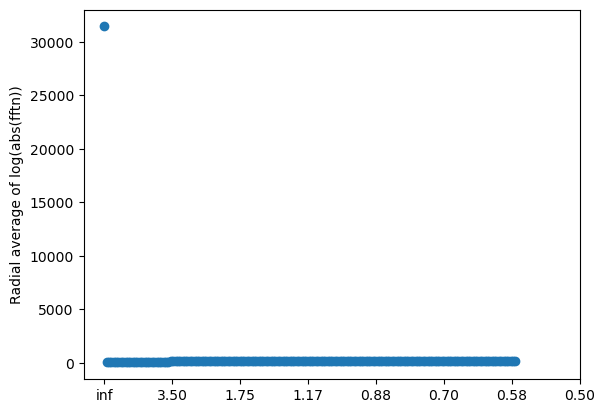

In [58]:
nticks = 8
maxk = 2
plt.scatter(k, mdsim_ice_deltas_f_abs_avg_radial)
plt.xticks(
    torch.linspace(0, maxk, nticks),
    labels=[f"{1/k:.2f}" for k in torch.linspace(0, maxk, nticks)],
)
plt.ylabel("Radial average of log(abs(fftn))")
plt.show()

## Interpolate to larger FOV

In [153]:
n = 100
dx = 1

In [154]:
icemake.interpolate_mdsim_f_kernel(n, dx)

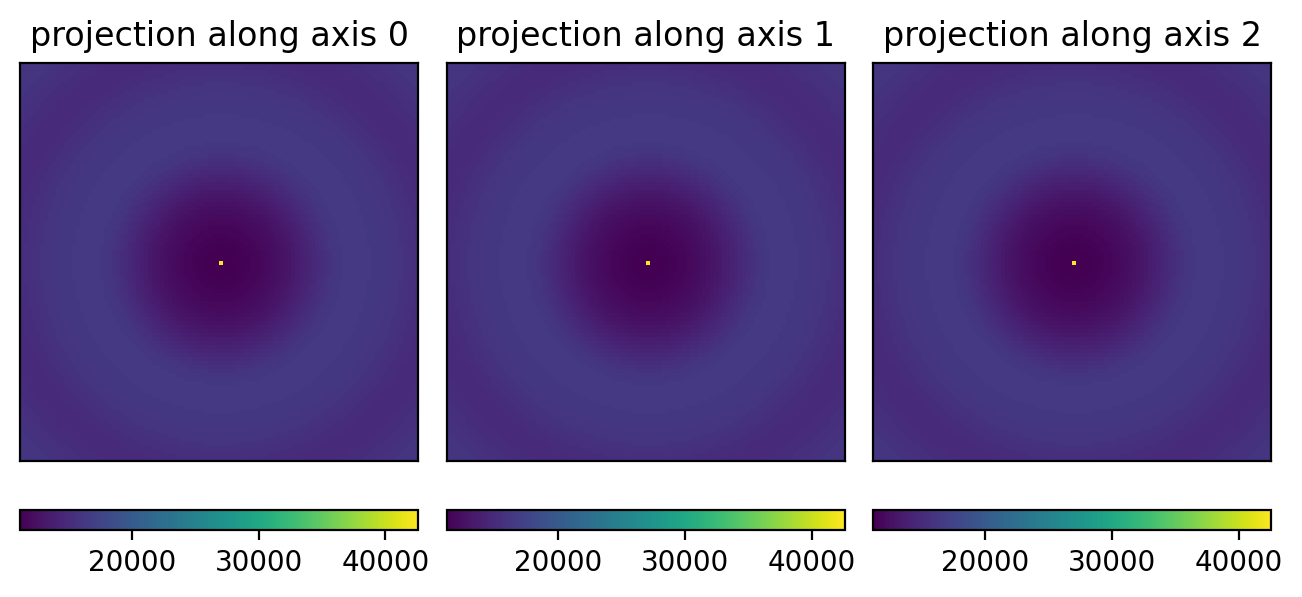

In [155]:
plot3d(icemake.interp_f_kernel)

## Generate initial positions

In [156]:
icemake.create_initial_ice_volume(n=n, dx=dx)

In [157]:
icemake.generate_ice(n=n, dx=dx, min_distance=1)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:21<00:00,  4.24s/it]


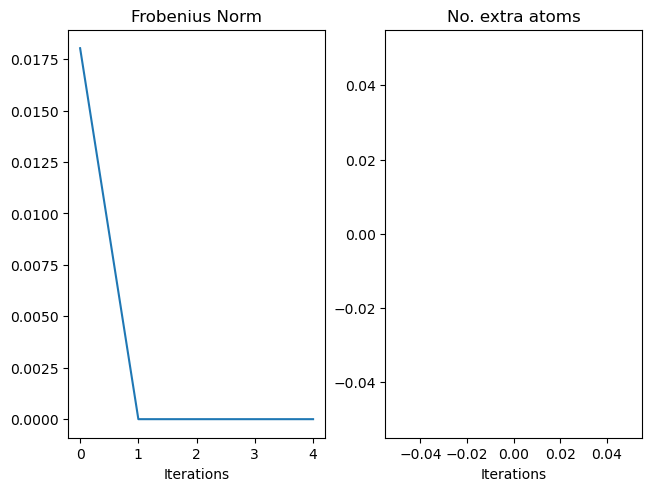

In [158]:
fig, axes = plt.subplots(1, 2, constrained_layout=True)
ax = axes[0]
ax.plot(icemake.frob_norm)
ax.set_title("Frobenius Norm")
ax.set_xlabel("Iterations")

ax = axes[1]
ax.plot(icemake.n_extra_atoms)
ax.set_title("No. extra atoms")
ax.set_xlabel("Iterations")
plt.show()

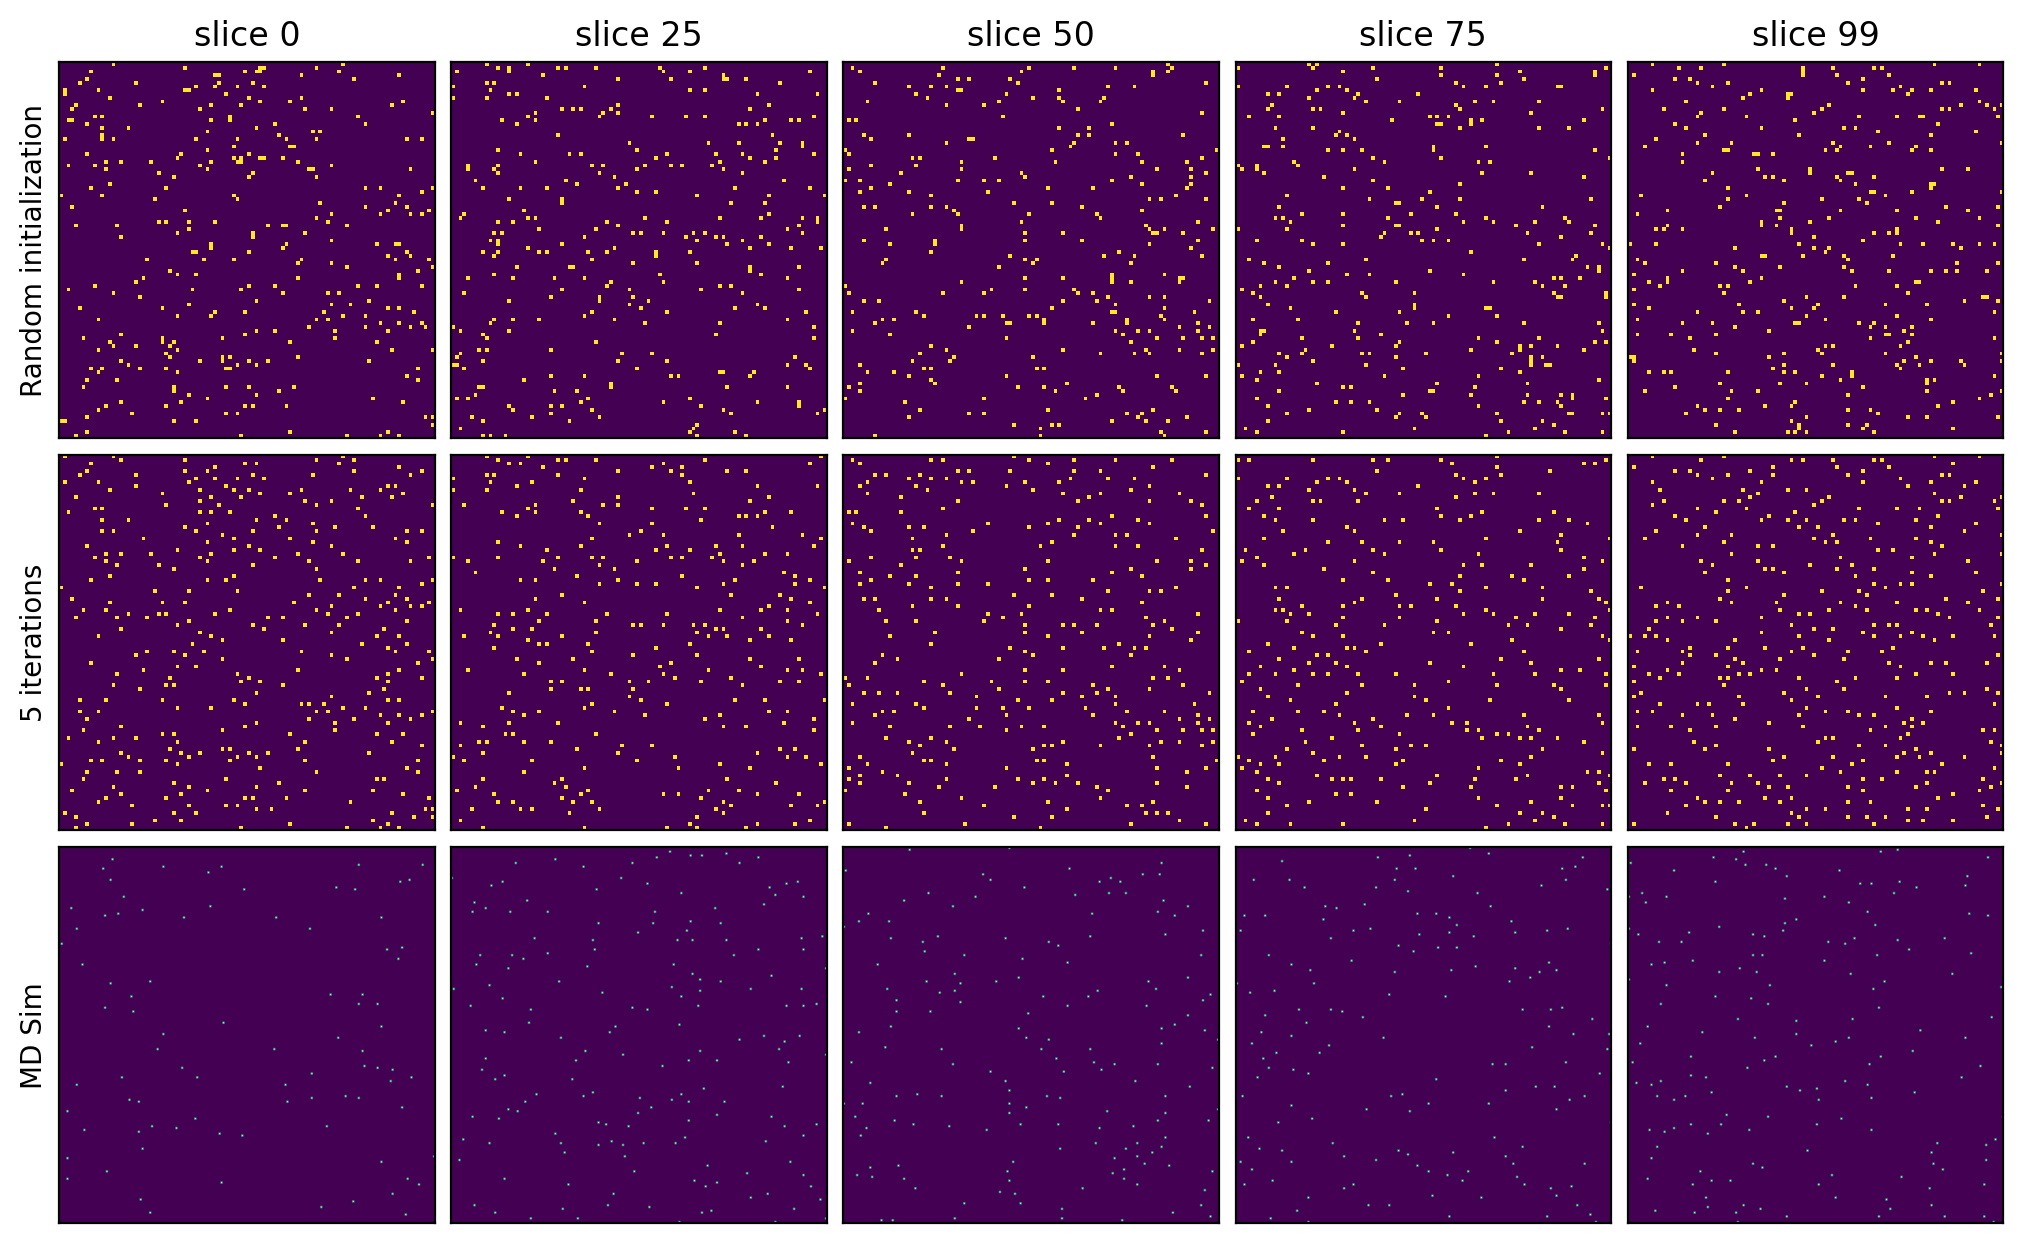

In [161]:
fig, axes = plt.subplots(3, 5, constrained_layout=True, figsize=(10, 6.1), dpi=200)
[ax.set(xticks=[], yticks=[]) for ax in axes.ravel()]
for i in range(5):
    if i == 4:
        idx = n-1
    else:
        idx = i * n//4
    ax = axes[0, i]
    ax.imshow(icemake.ice_vol_init[idx])
    ax.set_title(f"slice {idx}")

    ax = axes[1, i]
    ax.imshow(icemake.current_ice_vol[idx])

    ax = axes[2, i]
    ax.imshow(icemake.mdsim_ice_deltas[-1][idx])
axes[0, 0].set_ylabel("Random initialization")
axes[1, 0].set_ylabel(f"{5} iterations")
axes[2, 0].set_ylabel("MD Sim")
plt.show()

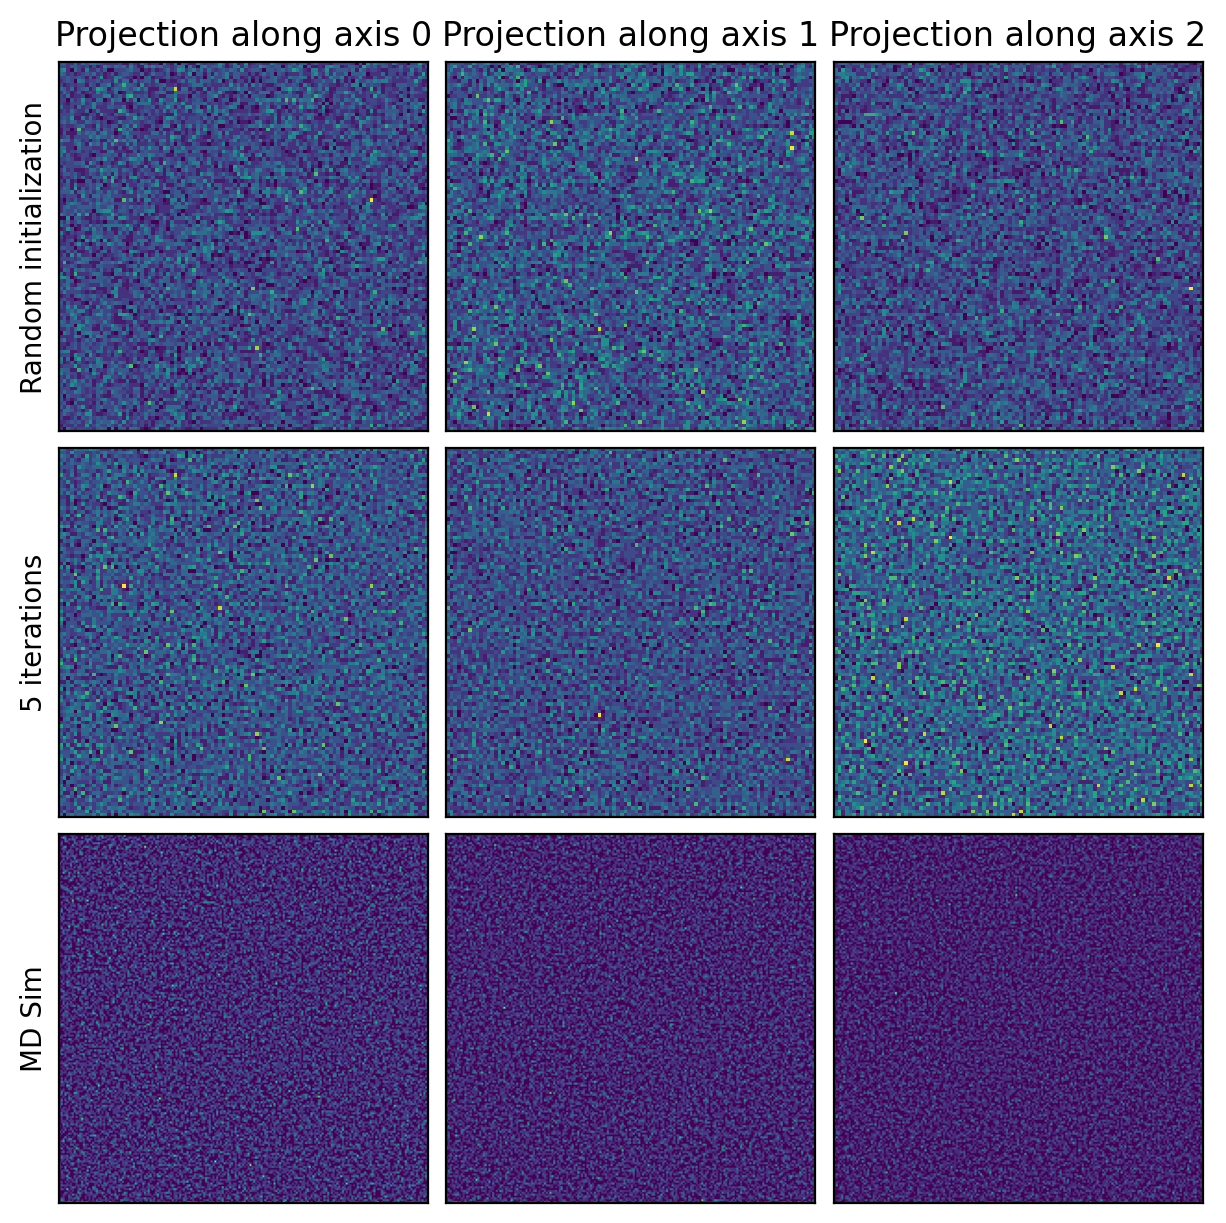

In [162]:
fig, axes = plt.subplots(3, 3, constrained_layout=True, figsize=(6, 6), dpi=200)
[ax.set(xticks=[], yticks=[]) for ax in axes.ravel()]
for i in range(3):
    ax = axes[0, i]
    ax.imshow(icemake.ice_vol_init.sum(dim=i))
    ax.set_title(f"Projection along axis {i}")

    ax = axes[1, i]
    ax.imshow(icemake.current_ice_vol.sum(dim=i))

    ax = axes[2, i]
    ax.imshow(icemake.mdsim_ice_deltas[-1].sum(dim=i))
axes[0, 0].set_ylabel("Random initialization")
axes[1, 0].set_ylabel(f"{5} iterations")
axes[2, 0].set_ylabel("MD Sim")
plt.show()

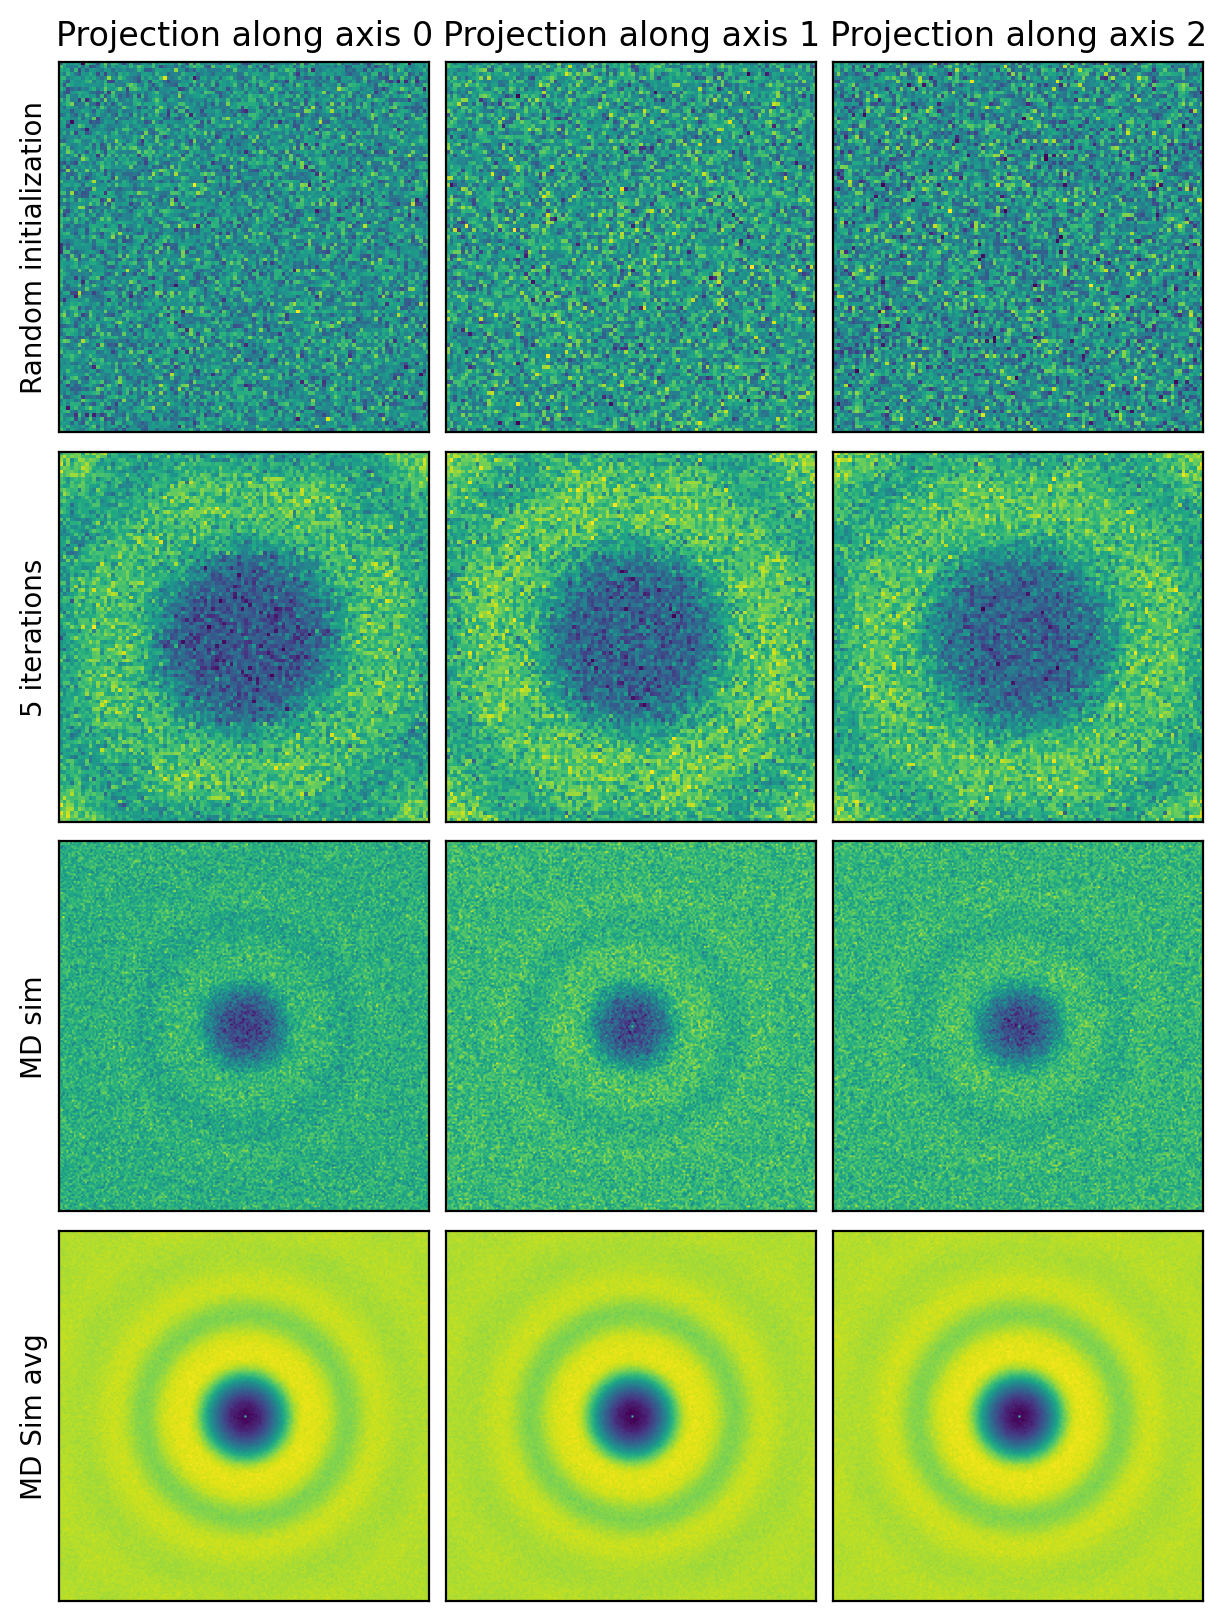

In [163]:
ice_vol_init_logabsf = torch.log(torch.abs(fftn(icemake.ice_vol_init)))
ice_vol_logabsf = torch.log(torch.abs(fftn(icemake.current_ice_vol)))
mdsim_ice_delta_logabsf_avg = torch.log(torch.abs(icemake.mdsim_ice_deltas_f))
mdsim_ice_delta_logabsf = torch.log(torch.abs(fftn(icemake.mdsim_ice_deltas[-1])))

fig, axes = plt.subplots(4, 3, constrained_layout=True, figsize=(6, 8), dpi=200)
[ax.set(xticks=[], yticks=[]) for ax in axes.ravel()]
for i in range(3):
    ax = axes[0, i]
    ax.imshow(ice_vol_init_logabsf.sum(dim=i))
    ax.set_title(f"Projection along axis {i}")

    ax = axes[1, i]
    ax.imshow(ice_vol_logabsf.sum(dim=i))

    ax = axes[2, i]
    ax.imshow(mdsim_ice_delta_logabsf.sum(dim=i))

    ax = axes[3, i]
    ax.imshow(mdsim_ice_delta_logabsf_avg.sum(dim=i))
axes[0, 0].set_ylabel("Random initialization")
axes[1, 0].set_ylabel(f"{5} iterations")
axes[2, 0].set_ylabel("MD sim")
axes[3, 0].set_ylabel("MD Sim avg")
plt.show()

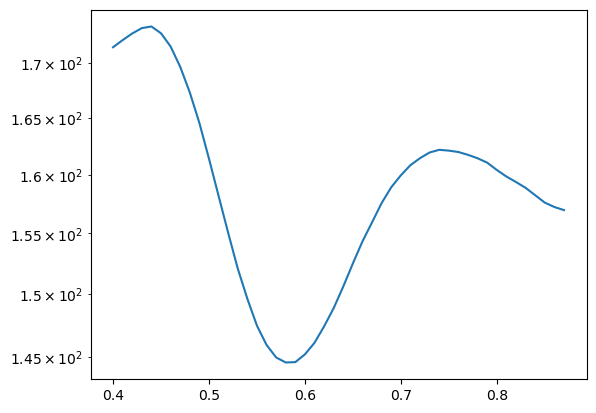

In [164]:
plt.semilogy(icemake.interp_radial_k[40:], icemake.interp_f_radial_avg[40:])

In [ ]:
plt.semilogy(icemake.interp_radial_k[40:], icemake.interp_f_radial_avg[40:])

In [ ]:
plt.semilogy(icemake.interp_radial_k[40:], icemake.interp_f_radial_avg[40:])

In [136]:
blah = radial_profile_3d(torch.abs(fftn(icemake.current_ice_vol)))

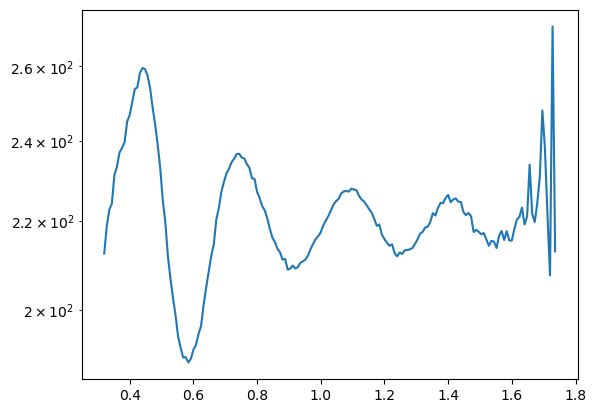

In [139]:
plt.semilogy(icemake.interp_radial_k[40:], blah[40:])